Import packages

In [1]:
import math
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from matplotlib import pyplot as plt

Dataset

201

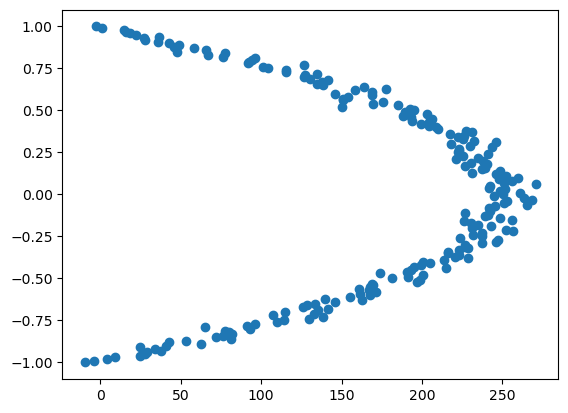

In [2]:
R=1
r=np.arange(-1,1.01,0.01)
G=1
mu=0.001
u=G/(4*mu)*(R**2-r**2)+10*np.random.randn(len(r))
plt.scatter(u,r)
r=torch.tensor(r)
u=torch.tensor(u)
len(r)

Split the data set

In [3]:
val_ratio=0.2
n_sample=len(r)
shuffle_ind=torch.randperm(len(r))
train_ind=shuffle_ind[:-int(val_ratio*n_sample)]
val_ind=shuffle_ind[-int(val_ratio*n_sample):]
train_set_r=r[train_ind]
train_set_r=r[train_ind].unsqueeze(1)
train_set_u=u[train_ind].unsqueeze(1)
val_set_r=r[val_ind].unsqueeze(1)
val_set_u=u[val_ind].unsqueeze(1)

train_set_r=train_set_r.to(torch.float32)
train_set_u=train_set_u.to(torch.float32)
val_set_r=val_set_r.to(torch.float32)
val_set_u=val_set_u.to(torch.float32)

Model

In [4]:
#Fully connective nueral netwoek
''' Homework!!! You have to fill the number in this block to achieve basic score '''
#Attention! XX1 in first layer is identical in second layer, so as XX2 XX3 XX4
#suggest  all XX range  from 1~600, and gradually diverge then converge
fc_model=nn.Sequential(
         nn.Linear(1,XX1),
         nn.Tanh(),
         nn.Linear(XX1,XX2),
         nn.Tanh(),
    '''Homework!!! You can add more layer to let the model deeper, 
    withder or changing activative fiunction to achieve intermediate level '''
         nn.Linear(XX2,XX3),
         nn.Tanh(),
         nn.Linear(XX3,XX4),
         nn.Tanh(),
         nn.Linear(XX4,1))

Loss function

In [5]:
loss_fn=nn.MSELoss()

Configuration

In [6]:
''' Homework!!! You have to fill the number in this block to achieve basic grade '''
lr=XXXX # learning rate, suggest from 1e-3 to 1e-5
n_epoch=XXXXX # number of epoch, suggest from 10000 to 100000
best_loss=XXXXX #initial best loss, suggest large enogh like 100000

Optimizer

In [7]:
optimizer=optim.SGD(fc_model.parameters(),lr)

Training loop

In [8]:
def train(z_train,u_train,z_val,u_val,n_epoch,model,optimizer,loss_fn,best_loss):
    for epoch in range(1,n_epoch+1):
        u_p=model(z_train)
        train_loss=loss_fn(u_p,u_train)
        
        u_v=model(z_val)
        val_loss=loss_fn(u_v,u_val)
        
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        
        if val_loss<best_loss:
            best_loss=val_loss
            print(f"Best loss {best_loss}")
            
        print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"
              f"Validation loss {val_loss.item():.4f}")

Training !

In [9]:
train(train_set_r,train_set_u,val_set_r,val_set_u,n_epoch,fc_model,optimizer,loss_fn,best_loss)

Best loss 29987.375
Epoch 1, Training loss 33995.7773,Validation loss 29987.3750
Best loss 29964.990234375
Epoch 2, Training loss 33971.7383,Validation loss 29964.9902
Best loss 29942.46875
Epoch 3, Training loss 33947.5391,Validation loss 29942.4688
Best loss 29919.572265625
Epoch 4, Training loss 33922.9414,Validation loss 29919.5723
Best loss 29896.078125
Epoch 5, Training loss 33897.7031,Validation loss 29896.0781
Best loss 29871.74609375
Epoch 6, Training loss 33871.5625,Validation loss 29871.7461
Best loss 29846.333984375
Epoch 7, Training loss 33844.2617,Validation loss 29846.3340
Best loss 29819.57421875
Epoch 8, Training loss 33815.5078,Validation loss 29819.5742
Best loss 29791.17578125
Epoch 9, Training loss 33785.0039,Validation loss 29791.1758
Best loss 29760.833984375
Epoch 10, Training loss 33752.3945,Validation loss 29760.8340
Best loss 29728.208984375
Epoch 11, Training loss 33717.3359,Validation loss 29728.2090
Best loss 29692.9375
Epoch 12, Training loss 33679.4141,V

 Saving best model with best loss 5529.43798828125
Epoch 639, Training loss 6552.1318,Validation loss 5529.4380
 Saving best model with best loss 5525.20458984375
Epoch 640, Training loss 6549.5239,Validation loss 5525.2046
 Saving best model with best loss 5520.9951171875
Epoch 641, Training loss 6546.9331,Validation loss 5520.9951
 Saving best model with best loss 5516.80810546875
Epoch 642, Training loss 6544.3604,Validation loss 5516.8081
 Saving best model with best loss 5512.64501953125
Epoch 643, Training loss 6541.8052,Validation loss 5512.6450
 Saving best model with best loss 5508.50341796875
Epoch 644, Training loss 6539.2671,Validation loss 5508.5034
 Saving best model with best loss 5504.38525390625
Epoch 645, Training loss 6536.7451,Validation loss 5504.3853
 Saving best model with best loss 5500.2900390625
Epoch 646, Training loss 6534.2422,Validation loss 5500.2900
 Saving best model with best loss 5496.2158203125
Epoch 647, Training loss 6531.7549,Validation loss 5496.

 Saving best model with best loss 5227.18017578125
Epoch 729, Training loss 6376.0342,Validation loss 5227.1802
 Saving best model with best loss 5224.57177734375
Epoch 730, Training loss 6374.6221,Validation loss 5224.5718
 Saving best model with best loss 5221.97705078125
Epoch 731, Training loss 6373.2188,Validation loss 5221.9771
 Saving best model with best loss 5219.39501953125
Epoch 732, Training loss 6371.8247,Validation loss 5219.3950
 Saving best model with best loss 5216.8271484375
Epoch 733, Training loss 6370.4404,Validation loss 5216.8271
 Saving best model with best loss 5214.2724609375
Epoch 734, Training loss 6369.0654,Validation loss 5214.2725
 Saving best model with best loss 5211.7314453125
Epoch 735, Training loss 6367.6997,Validation loss 5211.7314
 Saving best model with best loss 5209.20263671875
Epoch 736, Training loss 6366.3433,Validation loss 5209.2026
 Saving best model with best loss 5206.6884765625
Epoch 737, Training loss 6364.9961,Validation loss 5206.6

 Saving best model with best loss 5047.2880859375
Epoch 814, Training loss 6284.5474,Validation loss 5047.2881
 Saving best model with best loss 5045.60009765625
Epoch 815, Training loss 6283.7549,Validation loss 5045.6001
 Saving best model with best loss 5043.921875
Epoch 816, Training loss 6282.9688,Validation loss 5043.9219
 Saving best model with best loss 5042.251953125
Epoch 817, Training loss 6282.1880,Validation loss 5042.2520
 Saving best model with best loss 5040.58935546875
Epoch 818, Training loss 6281.4121,Validation loss 5040.5894
 Saving best model with best loss 5038.93603515625
Epoch 819, Training loss 6280.6411,Validation loss 5038.9360
 Saving best model with best loss 5037.2900390625
Epoch 820, Training loss 6279.8755,Validation loss 5037.2900
 Saving best model with best loss 5035.65234375
Epoch 821, Training loss 6279.1157,Validation loss 5035.6523
 Saving best model with best loss 5034.02294921875
Epoch 822, Training loss 6278.3604,Validation loss 5034.0229
 Sav

 Saving best model with best loss 4934.3349609375
Epoch 895, Training loss 6235.0742,Validation loss 4934.3350
 Saving best model with best loss 4933.19921875
Epoch 896, Training loss 6234.6182,Validation loss 4933.1992
 Saving best model with best loss 4932.0693359375
Epoch 897, Training loss 6234.1646,Validation loss 4932.0693
 Saving best model with best loss 4930.94482421875
Epoch 898, Training loss 6233.7148,Validation loss 4930.9448
 Saving best model with best loss 4929.8251953125
Epoch 899, Training loss 6233.2681,Validation loss 4929.8252
 Saving best model with best loss 4928.7109375
Epoch 900, Training loss 6232.8237,Validation loss 4928.7109
 Saving best model with best loss 4927.6025390625
Epoch 901, Training loss 6232.3833,Validation loss 4927.6025
 Saving best model with best loss 4926.4990234375
Epoch 902, Training loss 6231.9458,Validation loss 4926.4990
 Saving best model with best loss 4925.40087890625
Epoch 903, Training loss 6231.5098,Validation loss 4925.4009
 Sav

...

Epoch 49241, Training loss 86.2491,Validation loss 123.0383
Epoch 49242, Training loss 86.1886,Validation loss 120.9125
Epoch 49243, Training loss 86.2482,Validation loss 123.0376
Epoch 49244, Training loss 86.1878,Validation loss 120.9130
Epoch 49245, Training loss 86.2474,Validation loss 123.0369
Epoch 49246, Training loss 86.1869,Validation loss 120.9138
Epoch 49247, Training loss 86.2465,Validation loss 123.0361
Epoch 49248, Training loss 86.1860,Validation loss 120.9142
Epoch 49249, Training loss 86.2456,Validation loss 123.0354
Epoch 49250, Training loss 86.1851,Validation loss 120.9148
Epoch 49251, Training loss 86.2447,Validation loss 123.0348
Epoch 49252, Training loss 86.1842,Validation loss 120.9154
Epoch 49253, Training loss 86.2438,Validation loss 123.0341
Epoch 49254, Training loss 86.1834,Validation loss 120.9160
Epoch 49255, Training loss 86.2429,Validation loss 123.0333
Epoch 49256, Training loss 86.1825,Validation loss 120.9165
Epoch 49257, Training loss 86.2420,Valid

Epoch 49449, Training loss 86.1521,Validation loss 122.9596
Epoch 49450, Training loss 86.0928,Validation loss 120.9742
Epoch 49451, Training loss 86.1511,Validation loss 122.9588
Epoch 49452, Training loss 86.0918,Validation loss 120.9749
Epoch 49453, Training loss 86.1501,Validation loss 122.9580
Epoch 49454, Training loss 86.0908,Validation loss 120.9755
Epoch 49455, Training loss 86.1491,Validation loss 122.9573
Epoch 49456, Training loss 86.0899,Validation loss 120.9762
Epoch 49457, Training loss 86.1482,Validation loss 122.9565
Epoch 49458, Training loss 86.0889,Validation loss 120.9769
Epoch 49459, Training loss 86.1472,Validation loss 122.9557
Epoch 49460, Training loss 86.0880,Validation loss 120.9775
Epoch 49461, Training loss 86.1462,Validation loss 122.9549
Epoch 49462, Training loss 86.0870,Validation loss 120.9781
Epoch 49463, Training loss 86.1451,Validation loss 122.9541
Epoch 49464, Training loss 86.0860,Validation loss 120.9787
Epoch 49465, Training loss 86.1442,Valid

Epoch 49659, Training loss 86.0446,Validation loss 122.8754
Epoch 49660, Training loss 85.9871,Validation loss 121.0446
Epoch 49661, Training loss 86.0435,Validation loss 122.8745
Epoch 49662, Training loss 85.9860,Validation loss 121.0452
Epoch 49663, Training loss 86.0425,Validation loss 122.8737
Epoch 49664, Training loss 85.9849,Validation loss 121.0458
Epoch 49665, Training loss 86.0414,Validation loss 122.8729
Epoch 49666, Training loss 85.9839,Validation loss 121.0465
Epoch 49667, Training loss 86.0403,Validation loss 122.8720
Epoch 49668, Training loss 85.9828,Validation loss 121.0473
Epoch 49669, Training loss 86.0393,Validation loss 122.8712
Epoch 49670, Training loss 85.9818,Validation loss 121.0481
Epoch 49671, Training loss 86.0382,Validation loss 122.8704
Epoch 49672, Training loss 85.9808,Validation loss 121.0488
Epoch 49673, Training loss 86.0372,Validation loss 122.8696
Epoch 49674, Training loss 85.9798,Validation loss 121.0495
Epoch 49675, Training loss 86.0361,Valid

Epoch 49796, Training loss 85.9137,Validation loss 121.0942
Epoch 49797, Training loss 85.9687,Validation loss 122.8174
Epoch 49798, Training loss 85.9127,Validation loss 121.0950
Epoch 49799, Training loss 85.9676,Validation loss 122.8165
Epoch 49800, Training loss 85.9116,Validation loss 121.0958
Epoch 49801, Training loss 85.9665,Validation loss 122.8156
Epoch 49802, Training loss 85.9105,Validation loss 121.0967
Epoch 49803, Training loss 85.9654,Validation loss 122.8149
Epoch 49804, Training loss 85.9094,Validation loss 121.0975
Epoch 49805, Training loss 85.9643,Validation loss 122.8139
Epoch 49806, Training loss 85.9082,Validation loss 121.0982
Epoch 49807, Training loss 85.9631,Validation loss 122.8131
Epoch 49808, Training loss 85.9072,Validation loss 121.0988
Epoch 49809, Training loss 85.9620,Validation loss 122.8122
Epoch 49810, Training loss 85.9060,Validation loss 121.0996
Epoch 49811, Training loss 85.9608,Validation loss 122.8113
Epoch 49812, Training loss 85.9049,Valid

Epoch 49933, Training loss 85.8899,Validation loss 122.7583
Epoch 49934, Training loss 85.8355,Validation loss 121.1483
Epoch 49935, Training loss 85.8887,Validation loss 122.7575
Epoch 49936, Training loss 85.8344,Validation loss 121.1492
Epoch 49937, Training loss 85.8876,Validation loss 122.7565
Epoch 49938, Training loss 85.8332,Validation loss 121.1500
Epoch 49939, Training loss 85.8864,Validation loss 122.7556
Epoch 49940, Training loss 85.8320,Validation loss 121.1508
Epoch 49941, Training loss 85.8852,Validation loss 122.7547
Epoch 49942, Training loss 85.8309,Validation loss 121.1517
Epoch 49943, Training loss 85.8840,Validation loss 122.7540
Epoch 49944, Training loss 85.8297,Validation loss 121.1525
Epoch 49945, Training loss 85.8829,Validation loss 122.7531
Epoch 49946, Training loss 85.8286,Validation loss 121.1533
Epoch 49947, Training loss 85.8816,Validation loss 122.7523
Epoch 49948, Training loss 85.8274,Validation loss 121.1540
Epoch 49949, Training loss 85.8804,Valid

Plot the result

Text(0, 0.5, 'r radius (m)')

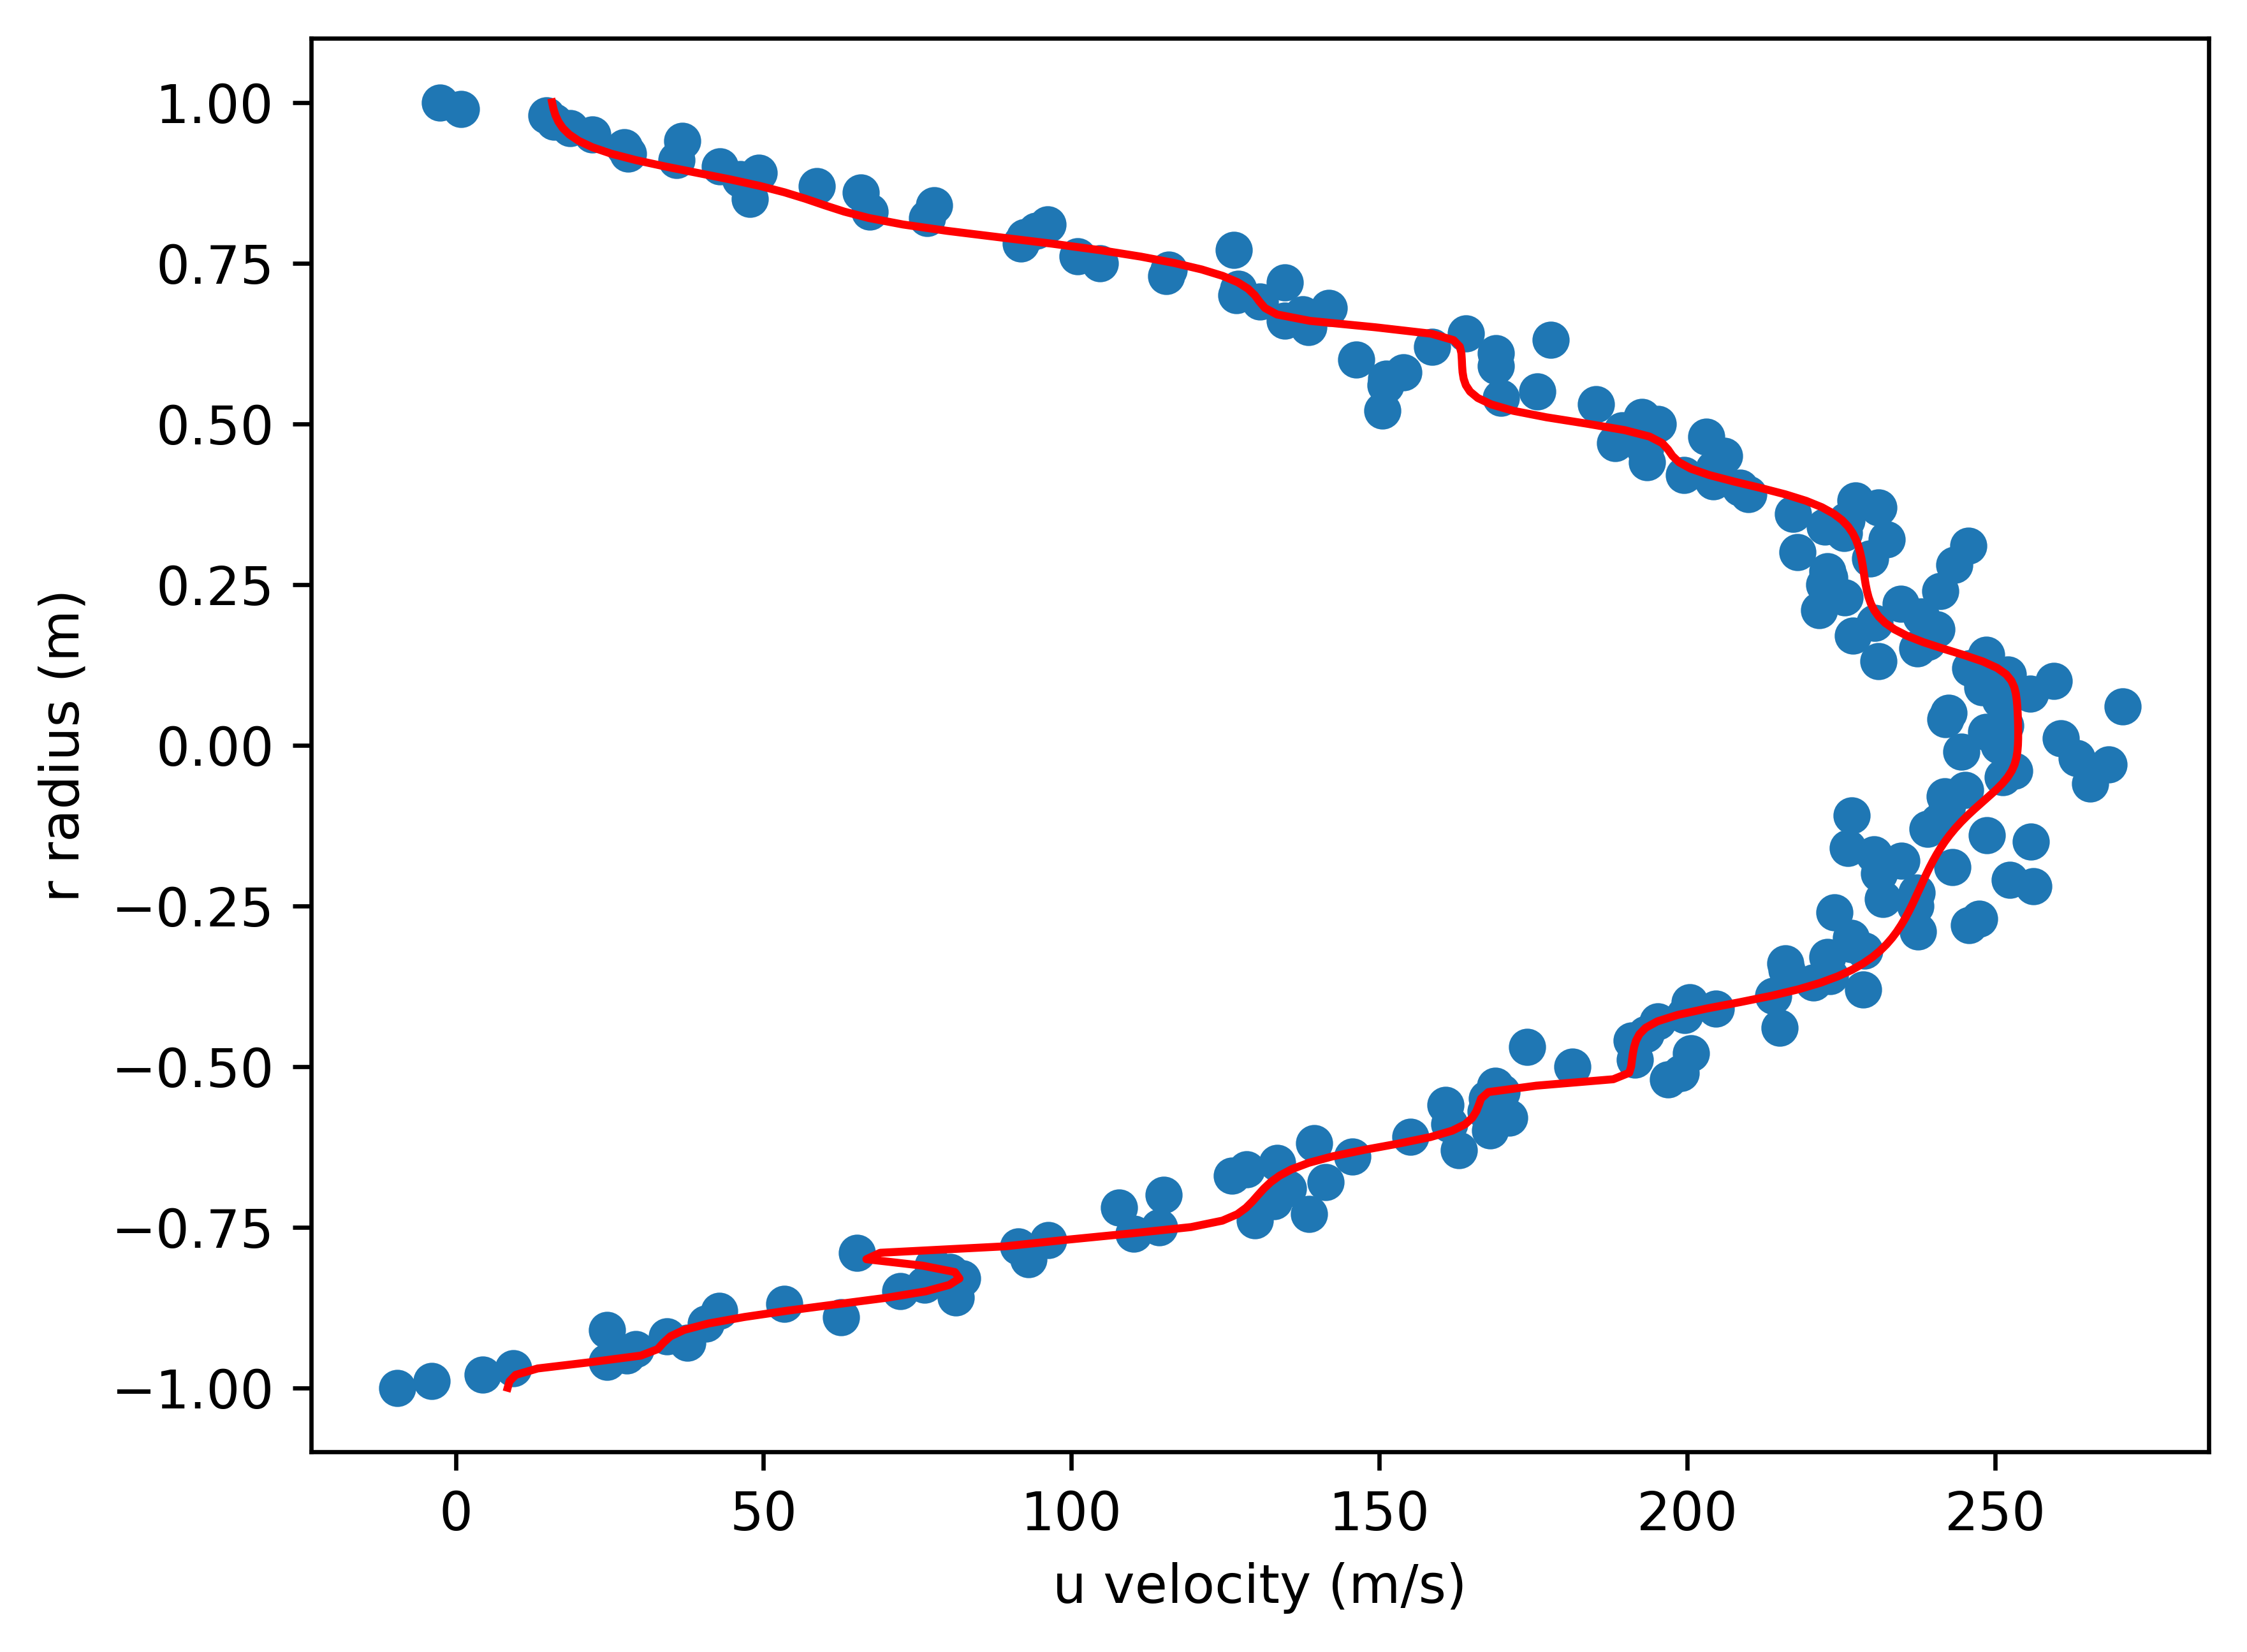

In [10]:
r=np.arange(-1,1.01,0.01)
r=torch.tensor(r).unsqueeze(1)
r=r.to(torch.float32)
u_p=fc_model(r)
fig=plt.figure(dpi=600)
plt.plot(u.numpy(),r.numpy(),'o')
plt.plot(u_p.detach().numpy(),r.numpy(),'r-')
plt.xlabel("u velocity (m/s)")
plt.ylabel("r radius (m)")